
# TabTransformer project Lasse Nordqvist

The aim of this project is to utilize a TabTransformer architecture for a binary classification task. The dataset for the classification task is from (https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis), and contains information about orders from a sports retailer.

The target variable from the dataset is the 'Late_delivery_risk', that is a label if the specific order delivery is late or not, based on the scheduled and realized delivery times for the order. If the realized order time is greater than the scheduled time, the delivery has a value 1 for the target variable. Otherwise, the value is 0.

The aim binary classification task is to predict the label of a specific order row, based on the other features present in the dataset. The task is carried out utilizing a TabTransformer architecture.

The TabTransformer architecture was first introduced by Huang et al. (2020) (https://doi.org/10.48550/arXiv.2012.06678), for the modeling and analysis of tabular data based on the Transformer architecture. The TabTransformer implementation in this project is based on the following sources: (https://aravindkolli.medium.com/mastering-tabular-data-with-tabtransformer-a-comprehensive-guide-119f6dbf5a79), (https://towardsdatascience.com/transformers-for-tabular-data-tabtransformer-deep-dive-5fb2438da820/) and (https://www.kaggle.com/code/antonsruberts/tabtransformer-w-pre-training?scriptVersionId=104250793).

A picture of the TabTransformer architecture can be found from all reference sources. The main feature is that categorical features are embedded and passed through transformer blocks to create numerical vectors of them. These vectors are then combined with the numerical features, and given to a multi-layer perceptron (MLP) as input. In this implementation, the MLP outputs a probability of the order row's binary class.

The dataset in use contains the following columns:

Type: Type of transaction made

Days for shipping (real): Actual shipping days of the purchased product

Days for shipment (scheduled): Days of scheduled delivery of the purchased product

Benefit per order: Earnings per order placed

Sales per customer: Total sales per customer made per customer

Delivery Status: Delivery status of orders (Advance shipping, Late delivery, Shipping canceled, Shipping on time)

Late_delivery_risk: Categorical variable indicating if sending is late (1) or not late (0)

Category Id: Product category code

Category Name: Description of the product category

Customer City: City where the customer made the purchase

Customer Country: Country where the customer made the purchase

Customer Email: Customer's email

Customer Fname: Customer name

Customer Id: Customer ID

Customer Lname: Customer lastname

Customer Password: Masked customer key

Customer Segment: Types of Customers (Consumer, Corporate, Home Office)

Customer State: State to which the store where the purchase is registered belongs

Customer Street: Street to which the store where the purchase is registered belongs

Customer Zipcode: Customer Zipcode

Department Id: Department code of store

Department Name: Department name of store

Latitude: Latitude corresponding to location of store

Longitude: Longitude corresponding to location of store

Market: Market to where the order is delivered (Africa, Europe, LATAM, Pacific Asia, USCA)

Order City: Destination city of the order

Order Country: Destination country of the order

Order Customer Id: Customer order code

order date (DateOrders): Date on which the order is made

Order Id: Order code

Order Item Cardprod Id: Product code generated through the RFID reader

Order Item Discount: Order item discount value

Order Item Discount Rate: Order item discount percentage

Order Item Id: Order item code

Order Item Product Price: Price of products without discount

Order Item Profit Ratio: Order Item Profit Ratio

Order Item Quantity: Number of products per order

Sales: Value in sales

Order Item Total: Total amount per order

Order Profit Per Order: Order Profit Per Order

Order Region: Region of the world where the order is delivered

Order State: State of the region where the order is delivered

Order Status: Status of the order (COMPLETE, PENDING, CLOSED, PENDING_PAYMENT, CANCELED, PROCESSING, SUSPECTED_FRAUD, ON_HOLD, PAYMENT_REVIEW)

Product Card Id: Product code

Product Category Id: Product category code

Product Description: Product Description

Product Image: Link of visit and purchase of the product

Product Name: Product Name

Product Price: Product Price

Product Status: Status of the product stock (1: not available, 0: available)

Shipping date (DateOrders): Exact date and time of shipment

Shipping Mode: Shipping modes (Standard Class, First Class, Second Class, Same Day)

In [ ]:
# Library for accessing resources in Kagglehub, one of the biggest data science
# communities in the world.
import kagglehub
# Python library for data analysis and manipulation
import pandas as pd
# Python library for high-dimensional computation
import numpy as np
# Sk-learn function for the train-test-validation split of the dataset
from sklearn.model_selection import train_test_split
# Sk-learn functions for ordinal encoding of categorical features and for the
# normalization of the datapoints
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
# Sk-learn function to separate columns in dataset for different transformation
# operations
from sklearn.compose import ColumnTransformer
# Tensorflow library for deep learning
import tensorflow as tf
# Tensorflow module for creating layers in neural networks
from tensorflow.keras import layers
# Libraries for visualization of results
import matplotlib.pyplot as plt
import seaborn as sns
# Performance metrics to measure the performance of the binary classifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, fbeta_score
# Statistical tests for feature selection
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from scipy.stats import normaltest, f_oneway, mannwhitneyu
# Dataset containing information on orders from a sports retailer
path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")

# Reading the file manually with the correct encoding
df = pd.read_csv(f"{path}/DataCoSupplyChainDataset.csv", encoding='latin-1')

print("Loaded successfully!")

#~180,000 rows, 53 different features
print(df.shape)

# The target feature of this project is 'Late_delivery_risk', based on the
# scheduled and actual delivery time of the order. If the delivery was delivered
# late, the feature value is 1, otherwise 0.
print(df['Late_delivery_risk'].value_counts()/df.shape[0])
# ~55% of the rows of the have a 1 target label, ~45% 0, data set is
# balanced enough, so no artificial resampling is needed.

# Drop columns with any missing values
dropped_cols = df.columns[df.isna().any()].tolist()
print("Columns to be droppped:",dropped_cols)
df = df.dropna(axis=1)

# Cardinality of features a ratio of over 0.005 can be considered as an heuristi for
# too high cardinality for the categorical features embedder.
print("Cardinality of features:\n",df.nunique()/df.count())

# Preliminary features (all features from dataset except metadata, dropped features,
# features with high cardinality, and features derived from the target variable).

# Features split to numerical and categorical features.
cat_features = [
    'Type', 'Category Name', 'Customer City', 'Customer Country',
    'Customer Segment', 'Customer State', 'Department Name', 'Market',
    'Order Country', 'Order Region', 'Product Name', 'Shipping Mode', 'Product Status'
]
num_features = [
    'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer',
    'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity',
    'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price'
]

# Order dates can be relevant to a order being late or not. In reality, orders made
# during busy periods (e.g. Black Friday or before Christmas), have a higher
# chance of being late, due to the high volumes of orders made. Day of week and
# hours can also have an effect (e.g. order made Friday evening most likely has
# increased risk of being late).

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['month'] = df['order date (DateOrders)'].dt.month
df['week'] = df['order date (DateOrders)'].dt.isocalendar().week.astype(int)
df['day_of_week'] = df['order date (DateOrders)'].dt.dayofweek
df['hour'] = df['order date (DateOrders)'].dt.hour

# So that dates are accurately represented, cyclical encoding is used to encode
# the date values. If datetime values would be used, similar dates from different
# years (e.g. 20/12), would be handled as dissimilar. With cyclical encoding using
# sine and cosine functions, dates that are close by each other will be handled
# as similar (e.g. 31/12 and 1/1).

# Month (1-12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Week (1-52 or 53)
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

# Day of Week (0-6)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Hour (0-23)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

time_features = [
    'month_sin', 'month_cos',
    'week_sin', 'week_cos',
    'day_sin', 'day_cos',
    'hour_sin', 'hour_cos'
]

# Add time features to existing numerical feature list
num_features = num_features + time_features
target = 'Late_delivery_risk'

Using Colab cache for faster access to the 'dataco-smart-supply-chain-for-big-data-analysis' dataset.
Loaded successfully!
(180519, 53)
Late_delivery_risk
1   0.548291
0   0.451709
Name: count, dtype: float64
Columns to be droppped: ['Customer Lname', 'Customer Zipcode', 'Order Zipcode', 'Product Description']
Cardinality of features:
 Type                            0.000022
Days for shipping (real)        0.000039
Days for shipment (scheduled)   0.000022
Benefit per order               0.121860
Sales per customer              0.016214
Delivery Status                 0.000022
Late_delivery_risk              0.000011
Category Id                     0.000283
Category Name                   0.000277
Customer City                   0.003119
Customer Country                0.000011
Customer Email                  0.000006
Customer Fname                  0.004332
Customer Id                     0.114403
Customer Password               0.000006
Customer Segment                0.000017
Custom

In [ ]:
# After the preliminary features have been identified, statistical tests are carried out
# for feature selection. The train-test split is carried out first to avoid data leakage.

# Train-test-validation split (80/10/10)
X = df[cat_features + num_features]
y = df[target]
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Encoding of categorical features and normalization numerical features is done
# after train-test-validation split to avoid data leakage between train, test,
# and validation sets.

# Ordinal encoding for categorical features. Ordinal encoding can be used, because
# features are turned into embedding vedtors in the transformer architecture
# removing the ordinal nature of the encodings. These embedding vectors
# change during the training of the model, pushing the embedding vectors of
# feature values that generate similar outputs closer together. Categorical
# feature values that are unseen in the training data get the encoding value -1.

# Temproray dataframes are created to conduct the statistical tests on the features
X_train_cat = X_train[cat_features].copy()
X_train_num = X_train[num_features].copy()

# A temporary ordinal encoder is used to encode the categorical features for the Chi-Squared test
temp_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat_encoded = temp_encoder.fit_transform(X_train_cat)

# Statistical significance of categorical features
selector_cat = SelectKBest(score_func=chi2, k='all')
selector_cat.fit(X_train_cat_encoded, y_train)

# Statistical signifigance of numerical features
def automated_statistical_testing(df, num_features, target):
    results = []

    for feature in num_features:
        # Get the pair of the target and current feature
        data = df[[feature, target]]

        # Check normality of feature in dataset
        stat, p_norm = normaltest(data[feature])
        is_normal = p_norm > 0.05

        # Split data into groups based on the target feature
        group_late = data[data[target] == 1][feature]
        group_ontime = data[data[target] == 0][feature]

        # Apply the appropriate test based on the normality of the feature's distribution
        if is_normal:
            # Parametric test for normally distributed data
            test_name = "ANOVA (F-test)"
            _, p_value = f_oneway(group_late, group_ontime)
        else:
            # Non-parametric test for non-normal data
            test_name = "Mann-Whitney U"
            _, p_value = mannwhitneyu(group_late, group_ontime)

        results.append({
            'Feature': feature,
            'Distribution': 'Normal' if is_normal else 'Non-Normal',
            'Test Used': test_name,
            'P-Value': p_value
        })

    # Convert results to a DataFrame for easy viewing
    results_df = pd.DataFrame(results)

    return results_df.sort_values(by='P-Value')

# Format P-values to decimal
pd.options.display.float_format = '{:.6f}'.format

# Using the function to conduct statistical tests for features
# Temporary dataframe so that statistical tests can be conducted
train_df = pd.concat([X_train, y_train], axis=1)
stats_report = automated_statistical_testing(train_df, num_features, target)
print(stats_report)

# View the p-values of categorical variables

feature_scores = pd.DataFrame({'Feature': cat_features, 'P-Value': selector_cat.pvalues_})
print(feature_scores.sort_values(by='P-Value'))

                          Feature Distribution       Test Used  P-Value
0   Days for shipment (scheduled)   Non-Normal  Mann-Whitney U 0.000000
20                       hour_sin   Non-Normal  Mann-Whitney U 0.000000
21                       hour_cos   Non-Normal  Mann-Whitney U 0.000818
16                       week_sin   Non-Normal  Mann-Whitney U 0.060444
14                      month_sin   Non-Normal  Mann-Whitney U 0.111260
19                        day_cos   Non-Normal  Mann-Whitney U 0.338650
12         Order Profit Per Order   Non-Normal  Mann-Whitney U 0.466742
1               Benefit per order   Non-Normal  Mann-Whitney U 0.466742
9             Order Item Quantity   Non-Normal  Mann-Whitney U 0.578073
15                      month_cos   Non-Normal  Mann-Whitney U 0.598768
10                          Sales   Non-Normal  Mann-Whitney U 0.649700
17                       week_cos   Non-Normal  Mann-Whitney U 0.683354
5             Order Item Discount   Non-Normal  Mann-Whitney U 0

In [ ]:
# Based on the computed p-values, features that show a statistically significant contribution
# to the target feature are selected as features to the model.
cat_features = [
    'Shipping Mode',
    'Customer City',
    'Type',
    'Order Country',
    'Order Region',
    'Product Name',
    'Category Name'
]
num_features = [
    'Days for shipment (scheduled)',
    'hour_sin',
    'hour_cos'
]

selected_features = cat_features + num_features

# Re-defining the train/test/validation test sets with the new features
X_train = X_train[selected_features].copy()
X_val = X_val[selected_features].copy()
X_test = X_test[selected_features].copy()

# Define the proper transformer operations for the numerical (normalization) and
# categorical features (ordinal encoding).
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

# Fit and transform training and test data
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# Access the fitted OrdinalEncoder to see the number of unique categorical
# feature values in the training set.
fitted_encoder = preprocessor.named_transformers_['cat']

# Vocab_sizes dictionary includes the number of unique value encodings in the
# training set for each categorical feature. The vocab_sizes defines the
# 'input_dim' for each embedding layer and tells the model the number of rows
# to create in its lookup tables.
vocab_sizes = {}
for i, col in enumerate(cat_features):
    # +1 is added to the length to account for the "Unknown" category in the
    # ordinal encoding.
    vocab_sizes[col] = len(fitted_encoder.categories_[i]) + 1

# Function to transform the data into dictionary a format for Keras Multi-Input
# where keys are the names of features and values are the columns containing
# the value of features. After the data transformation, the data is stored as
# a flat numpy array, which are given as input to the function.
def get_model_inputs(data_array):
    inputs = {}
    # cat_features came first in ColumnTransformer so they are handled first.
    for i, col_name in enumerate(cat_features):
        # +1 is added to all ordinal encodings, because the Keras embedding
        # layers don't accept negative indices. The shift means that the
        # 'Unknown' categorical labels will now start at index position 0.
        inputs[col_name] = data_array[:, i] + 1

    # The index of the num_features are offset with number of cat_features
    start_index_num = len(cat_features)
    for i, col_name in enumerate(num_features):
        inputs[col_name] = data_array[:, start_index_num + i]
    # The returned value is the part of the data set (train, val, test) as a
    # Keras-formatted dictionary.
    return inputs

train_inputs = get_model_inputs(X_train_transformed)
val_inputs = get_model_inputs(X_val_transformed)
test_inputs = get_model_inputs(X_test_transformed)

In [ ]:
# Cell that creates the tab transformer, based on the Medium and towards data
# science articles and TabTransformer Python library, links at the start of the
# report.
# Function inputs:
# vocab_size: dictionary that includes the number of unique values in categorical
# features + 1 unknown.
# num_features: list of numerical features
# embed_dim: the number of dimensions in the embedding vectores of categorical
# features
# num_heads: number of attention heads in the model
# num_blocks: number of transformer layers stacked on top of each other in the
# embedding of categorical variables.
def create_tab_transformer(vocab_sizes, num_features, embed_dim=32, num_heads=4,
                           num_blocks=2):
    inputs = {}
    # List for the output of individual embedding layers
    cat_embeddings = []

    # Embedding of categorical variables
    for col, vocab_size in vocab_sizes.items():
        # An input layer is added for all categorical feature columns
        input_layer = layers.Input(shape=(1,), name=col)
        inputs[col] = input_layer
        # All categorical features are mapped vectors of fixed size
        embed = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(input_layer)
        cat_embeddings.append(embed)

    # Concatenates the categorical input layers into one vector size (batch_size
    # number of categorical features, embed_dim).
    x = layers.Concatenate(axis=1)(cat_embeddings)

    # Transformer Blocks
    for _ in range(num_blocks):
        # Self-Attention Mechanism allows the model to learn connections between
        # categorical features and how these connections affect the target value.
        # Multi-head attention allows the model to look at different connections
        # simultaneously.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )(x, x)
        # Adding the original embedding vectors back into the transformer so the
        # information inside the original vectors doesn't vanish.
        x = layers.Add()([x, attention_output])
        # Layer normalization ensures the embedding vector values stay within a
        # consistent range (no exploding or vanishing gradients)
        x = layers.LayerNormalization()(x)

        # Light feed forward network to assess the relevance of the found
        # connections by the attention mechanism.
        ff_output = layers.Dense(embed_dim, activation='relu')(x)
        # Another Add & Norm pattern
        x = layers.Add()([x, ff_output])
        x = layers.LayerNormalization()(x)

    # Flattens transformer output to size (batch_size, num_cat * embed_dim),
    # so it can be concatenated with the numerical features
    x_flattened = layers.Flatten()(x)

    # Numerical inputs are collected to a single vector and given their own
    # input layer.
    num_inputs = []
    for col in num_features:
        input_layer = layers.Input(shape=(1,), name=col)
        inputs[col] = input_layer
        num_inputs.append(input_layer)

    # Vector size (batch_size, number of numerical features)
    x_numerical = layers.Concatenate()(num_inputs)

    # Numerical features and the categorical features that have passed the
    # transformer are concatenated.
    concat = layers.Concatenate()([x_flattened, x_numerical])

    # A multi-layer perceptron is used interpret the connections between the
    # different features.
    # Normalizes the inputs to the MLP to stabilize training
    x = layers.BatchNormalization()(concat)

    mlp = layers.Dense(128, activation='relu')(x)
    # Dropout is implemented (deactivates some neurons), so the model doesn't
    # overfit into the training data.
    mlp = layers.Dropout(0.2)(mlp)
    # The number of neurons is lowered so that the most important connections
    # are kept for the final estimation.
    mlp = layers.Dense(64, activation='relu')(mlp)
    # The final layer has a sigmoid function, that represents the probability,
    # that the model approximates that a certain datapoint should be given a
    # 'Late delivery risk' flag
    output = layers.Dense(1, activation='sigmoid')(mlp)
    # Constructs and returns the Keras model object
    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model

model = create_tab_transformer(vocab_sizes, num_features)

# Binary cross-entropy is chosen as the loss function, penalizing for confident
# predictions that are incorrect.
model.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC()])

In [ ]:
# Early stop mechanism to stop training if the model starts overfitting to
# training data.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3, # Stops training if the validation loss doesn't improve in 3 epochs
    restore_best_weights=True
)
# More weight is given to the true target label because in reality, the negative
# implications for a company would be far greater if it would falsely label a
# late delivery as a on-time delivery than vice-versa.
weights = {0: 1.0, 1: 1.5}
# One training epoch with the model takes around 1 minutes (Google Colab is used)
history = model.fit(
    train_inputs,
    y_train,
    epochs=25, # With the current setting, convergence is reached in ~20 epochs
    batch_size=256,
    validation_data=(val_inputs, y_val),
    verbose=1,
    callbacks=[early_stop], # Stops training to stop overfitting
    class_weight=weights # Gives more weight to the true label in training
)

Epoch 1/25
565/565 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.6428 - auc_1: 0.7342 - loss: 0.7046 - val_accuracy: 0.6940 - val_auc_1: 0.7687 - val_loss: 0.5412
Epoch 2/25
565/565 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.6880 - auc_1: 0.7837 - loss: 0.6395 - val_accuracy: 0.7080 - val_auc_1: 0.7866 - val_loss: 0.5327
Epoch 3/25
565/565 ━━━━━━━━━━━━━━━━━━━━ 48s 85ms/step - accuracy: 0.6981 - auc_1: 0.8008 - loss: 0.6229 - val_accuracy: 0.6953 - val_auc_1: 0.7986 - val_loss: 0.5243
Epoch 4/25
565/565 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.7109 - auc_1: 0.8142 - loss: 0.6087 - val_accuracy: 0.7023 - val_auc_1: 0.8066 - val_loss: 0.5149
Epoch 5/25
565/565 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.7212 - auc_1: 0.8257 - loss: 0.5945 - val_accuracy: 0.7111 - val_auc_1: 0.8114 - val_loss: 0.5080
Epoch 6/25
565/565 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - accuracy: 0.7323 - auc_1: 0.8381 - loss: 0.5783 - val_accuracy: 0.7167 - val_auc_1: 0.8248 - val_loss: 0.5014
Epoc

565/565 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
              precision    recall  f1-score   support

     On Time       0.80      0.73      0.76      8154
        Late       0.79      0.85      0.82      9898

    accuracy                           0.80     18052
   macro avg       0.80      0.79      0.79     18052
weighted avg       0.80      0.80      0.80     18052



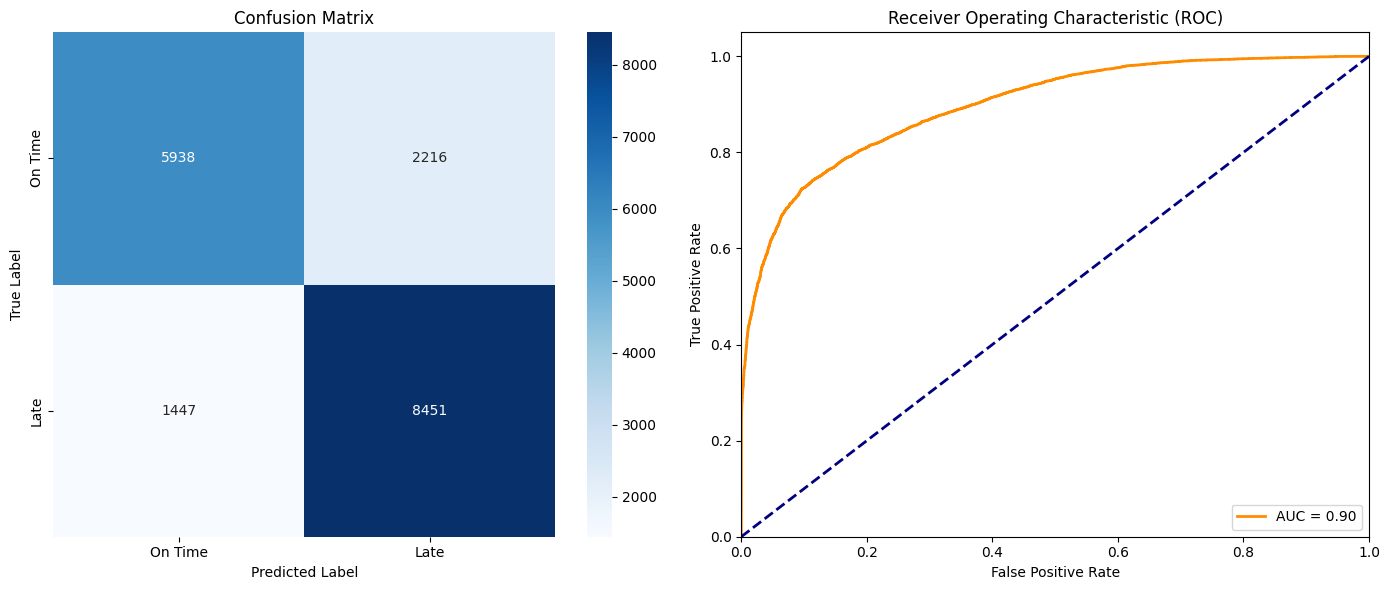

In [ ]:
# Probabilities of the target labels that the trained model generates for the
# test set data points (between 0 and 1).
y_pred_proba = model.predict(test_inputs).flatten()

# The probabilities of the labels are used to make a prediction of the target
# label (0 or 1). The base threshold is set at 0.5.
y_pred = (y_pred_proba > 0.5).astype(int)

# Classification report that includes the recall, accuracy etc. values for the
# different labels
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

# Plot for the confusion matrix and AUC curve
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Computing and plotting the confusion matrix of the model
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].set_xticklabels(['On Time', 'Late'])
ax[0].set_yticklabels(['On Time', 'Late'])

# Computing and plotting the ROC curve for the model
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

From a business perspective, the recall metric of the 'Late' label (TP/(TP+FN)) can be seen as the main performance metric. For a business, it would be more costly to falsely label a factually 'Late' order as an 'On time' order, than falsely labeling a factually 'On time' order.

As can be seen from the results, a recall value of 0.85 is achieved by using using the base threshold of 0.5. By weighing the 'Late' orders more during the training process, a better recall metric is achieved for the 'Late' label.

This project is a simple implementation on how the TabTransformer architecture can be used to analyze tabular data. This project doesn't include hyperparameter tuning, due to the computational time it would take. Through hyperparameter tuning, better results could be achieved (e.g. increasing number of attention heads, increasing the number of embedding dimensions, increasing the number of transformer blocks for categorical variables). The classifying threshold value could also be tuned for the best recall performance.